In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chisquare

In [2]:
url = "https://docs.google.com/spreadsheets/d/1z8H-8CxJXG2Hof3aHZmfOCACHsDuxkmDfxMTJwWCrD4/export?format=csv"
df = pd.read_csv(url)

# Example analysis
df.head() 



,Token,Submitted At,Respondent gender,Age Group,Institution category,Please rate your satisfaction with the quality of the lectures you receive,I think the course is designed in a way that meets the current tech industry needs,How many separate industrial trainings are you expected to complete in your department?,What programming languages were you exposed to in the school curriculum?
0,3iecc17hcyssjxsvos923iecc17fg2zb,2023-01-26T09:33:23Z,Male,20 to 24,University,4,NaN,NaN,NaN
1,79cmx9f35a8rkpzg5yyvz79cmlq1b7ma,2023-02-09T20:43:25Z,Male,20 to 24,Polytechnic,4,2.0,2.0,"FORTRAN, JavaScript, Java, C++, Python, C#, C,..."
2,guvgwczzamuzfti9rguv2g2j7qso42c0,2023-01-10T18:32:38Z,Male,20 to 24,University,3,2.0,1.0,"Java, Python"
3,9d6kacm78oea59bd9dyglv2ykut38xku,2023-01-26T18:00:00Z,Male,20 to 24,University,3,NaN,NaN,NaN
4,rjnc2lqphru2g0nt3bvtirjnc97xevrr,2023-01-23T17:39:49Z,Male,20 to 24,University,1,1.0,1.0,NaN


In [3]:
df.describe()  # Get summary statistics

,Please rate your satisfaction with the quality of the lectures you receive,I think the course is designed in a way that meets the current tech industry needs,How many separate industrial trainings are you expected to complete in your department?
count,250.000000,184.000000,165.000000
mean,3.056000,2.798913,1.624242
std,1.066496,1.186352,1.008207
min,1.000000,1.000000,0.000000
25%,3.000000,2.000000,1.000000
50%,3.000000,3.000000,1.000000
75%,4.000000,4.000000,2.000000
max,5.000000,5.000000,6.000000


# Q1.

In [4]:
# Assuming df is your loaded DataFrame

# Gender distribution
gender_counts = df['Respondent gender'].value_counts()
gender_percent = df['Respondent gender'].value_counts(normalize=True) * 100

# Age group distribution
age_counts = df['Age Group'].value_counts()
age_percent = df['Age Group'].value_counts(normalize=True) * 100

# Institution category distribution
inst_counts = df['Institution category'].value_counts()
inst_percent = df['Institution category'].value_counts(normalize=True) * 100

# Display nicely
print("Gender Distribution:")
print(pd.concat([gender_counts, gender_percent.rename("Percentage")], axis=1))

print("\nAge Group Distribution:")
print(pd.concat([age_counts, age_percent.rename("Percentage")], axis=1))

print("\nInstitution Category Distribution:")
print(pd.concat([inst_counts, inst_percent.rename("Percentage")], axis=1))


Gender Distribution:
                   count  Percentage
Respondent gender                   
Male                 142        56.8
Female               108        43.2

Age Group Distribution:
              count  Percentage
Age Group                      
20 to 24        182        72.8
Below 20         36        14.4
25 to 29         30        12.0
30 and above      2         0.8

Institution Category Distribution:
                      count  Percentage
Institution category                   
University              192        76.8
Polytechnic              44        17.6
College of Education     14         5.6


# Demographic Insights
## Gender:
The respondent pool shows a moderately balanced gender distribution, with 56.8% male and 43.2% female participants.

## Age Group:
A significant 72.8% of respondents fall within the 20 to 24 age group, suggesting that most are likely undergraduates or recent entrants into higher education. Other age groups — Below 20 (14.4%), 25 to 29 (12.0%), and 30 and above (0.8%) — make up a small fraction.

## Institution Category:
The dataset is dominated by university students (76.8%), with polytechnics (17.6%) and colleges of education (5.6%) making up the remainder. This indicates a heavier representation from university-level institutions.

# Q2.

In [5]:
# Drop rows where the column is missing or empty
lang_series = df["What programming languages were you exposed to in the school curriculum?"].dropna()

# Split each entry into individual languages and flatten into one list
all_languages = lang_series.str.split(',').explode().str.strip()

# Count frequency of each language
language_counts = all_languages.value_counts()

# Display the top languages
print(language_counts)


What programming languages were you exposed to in the school curriculum?
C++              56
Python           54
Java             48
BASIC            47
JavaScript       34
FORTRAN          30
C#               28
C                28
SQL              26
Visual Basic     17
MatLab           14
PHP               9
R                 3
Ruby on Rails     2
COBOL             1
iOS/Swift         1
Pascal            1
Name: count, dtype: int64


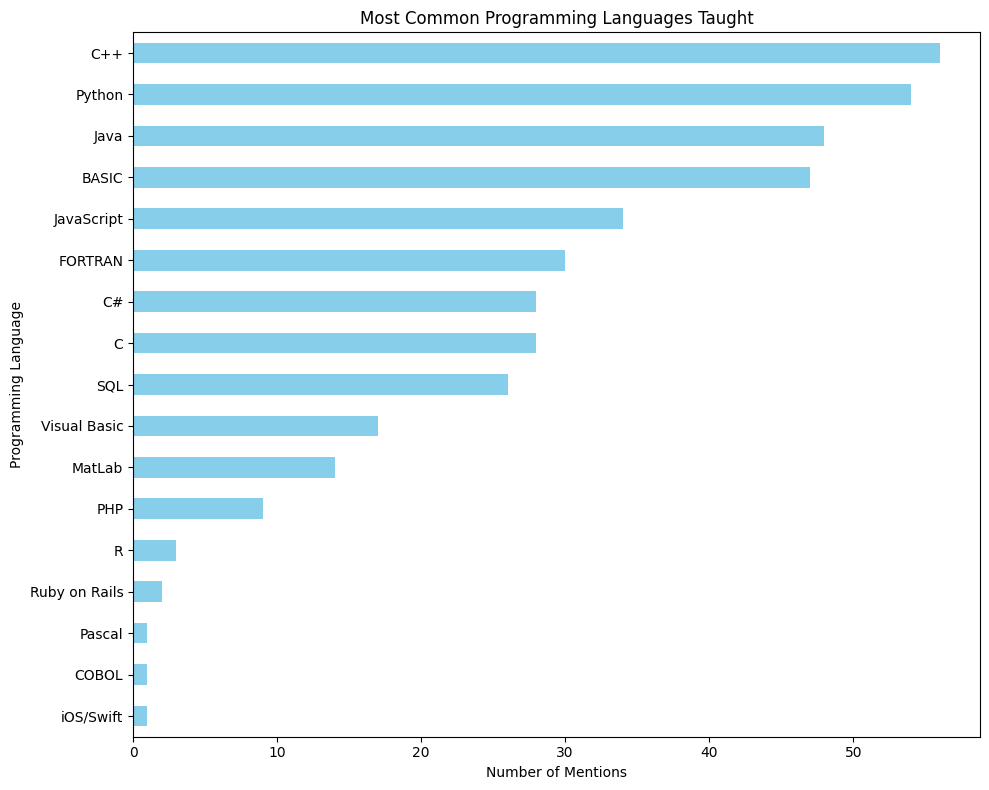

In [6]:
# Plot top languages
language_counts.sort_values().plot(kind='barh', figsize=(10, 8), color='skyblue')

plt.title("Most Common Programming Languages Taught")
plt.xlabel("Number of Mentions")
plt.ylabel("Programming Language")
plt.tight_layout()
plt.show()


**Top 3 Common Languages Students Were Exposed to:**

C++ (56 mentions) and Python (54) are nearly tied as the most commonly taught languages.

Java (48) follows closely behind, making up a strong trio of general-purpose programming instruction.

**Legacy or foundational languages like BASIC (47) and FORTRAN (30)** are surprisingly well-represented, suggesting some curricula still include older languages — possibly for historical or engineering-based instruction.

**Web and scripting languages** like JavaScript (34), PHP (9), and SQL (26) show moderate exposure, while R (3) and Ruby on Rails (2) have very limited adoption.

**Specialty languages** like MatLab (14) (for scientific computing), Visual Basic (17), and COBOL/Pascal/iOS/Swift (1 each) appear in niche pockets, likely tied to specific departments or legacy systems.

# Q3.

In [7]:
# Ensure the column is numeric and drop missing values
df['How many separate industrial trainings are you expected to complete in your department?'] = pd.to_numeric(
    df['How many separate industrial trainings are you expected to complete in your department?'], errors='coerce')

training_data = df['How many separate industrial trainings are you expected to complete in your department?'].dropna()

# Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(training_data, popmean=2)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")


t-statistic: -4.787
p-value: 0.000


**t-statistic** = -4.787: This shows the sample mean is significantly lower than the hypothesized value (2).

**p-value** = 0.000 (technically, p < 0.001):
This is well below the common significance threshold of 0.05.

There is strong statistical evidence that the average number of required industrial training sessions is not equal to 2. In fact, the negative t-value suggests it is less than 2 on average.

# Q4.

In [8]:
df['Please rate your satisfaction with the quality of the lectures you receive'].unique()

array([4, 3, 1, 5, 2])

In [9]:
# Ensure the satisfaction column is numeric and drop missing values
df['satisfaction'] = pd.to_numeric(
    df['Please rate your satisfaction with the quality of the lectures you receive'], errors='coerce')

satisfaction_data = df['satisfaction'].dropna()

# Validate the data range
if not satisfaction_data.between(1, 5).all():
    print("Warning: Some satisfaction scores are outside the valid range (1-5).")

# Check sample size
if len(satisfaction_data) < 30:
    print("Warning: Sample size is small (<30). Consider using a non-parametric test like Wilcoxon signed-rank.")

# Perform one-sample t-test (test against neutral value 3)
t_stat, p_value = stats.ttest_1samp(satisfaction_data, popmean=3)

# Print results
print(f"Mean satisfaction: {satisfaction_data.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.3f}) < {alpha}: Reject the null hypothesis. Satisfaction is significantly different from 3.")
    if satisfaction_data.mean() > 3:
        print("Students are generally satisfied.")
    else:
        print("Students are generally dissatisfied.")
else:
    print(f"p-value ({p_value:.3f}) >= {alpha}: Fail to reject the null hypothesis. No significant difference from neutral (3).")

Mean satisfaction: 3.06
t-statistic: 0.830
p-value: 0.407
p-value (0.407) >= 0.05: Fail to reject the null hypothesis. No significant difference from neutral (3).


## Interpretation of the Satisfaction Test
**Mean satisfaction** = 3.06: Slightly above neutral.

**t-statistic** = 0.830, **p-value** = 0.407: This p-value is much greater than 0.05, meaning the result is not statistically significant.

There is no strong statistical evidence that students' satisfaction with lecture quality is significantly different from neutral (i.e., "Indifferent"). While the average is slightly above 3, it is not enough to conclude that students are generally satisfied.

In [10]:
# Count the number of responses for each satisfaction rating
satisfaction_counts = df['satisfaction'].value_counts().sort_index()

# Display the counts of each satisfaction rating
print(satisfaction_counts)


satisfaction
1     29
2     27
3    116
4     57
5     21
Name: count, dtype: int64


In [11]:
df['Please rate your satisfaction with the quality of the lectures you receive'].isnull().sum()

np.int64(0)

# Q5.

In [13]:
# Convert the relevant column to numeric
df['industry_relevance'] = pd.to_numeric(
    df['I think the course is designed in a way that meets the current tech industry needs'], errors='coerce')

# Drop missing values
perception_data = df['industry_relevance'].dropna()

# Count the number of responses for each level (1 to 5)
observed_counts = perception_data.value_counts().sort_index()

# Define expected counts assuming uniform distribution
expected_counts = [len(perception_data) / 5] * 5  # Equal expectation for all 5 response levels

# Perform chi-square goodness-of-fit test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

# Output results
print("Observed counts:\n", observed_counts)
print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.3f}")


Observed counts:
 industry_relevance
1.0    35
2.0    34
3.0    60
4.0    43
5.0    12
Name: count, dtype: int64

Chi-square statistic: 32.685
p-value: 0.000


Students generally lean toward neutral or negative perceptions regarding whether their course design meets the current needs of the tech industry. While some agree, very few strongly agree, and a significant portion either disagrees or strongly disagrees.

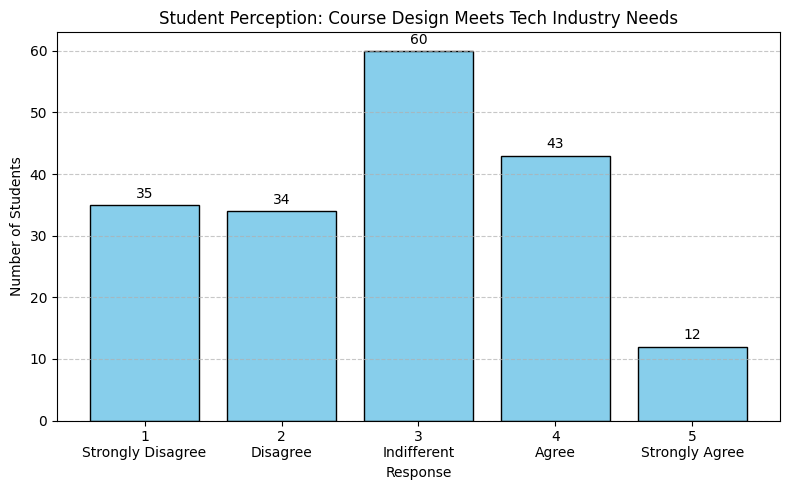

In [14]:
# Data from the chi-square result
response_labels = ['1\nStrongly Disagree', '2\nDisagree', '3\nIndifferent', '4\nAgree', '5\nStrongly Agree']
observed_counts = [35, 34, 60, 43, 12]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(response_labels, observed_counts, color='skyblue', edgecolor='black')
plt.title("Student Perception: Course Design Meets Tech Industry Needs")
plt.xlabel("Response")
plt.ylabel("Number of Students")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()
